# Baseline: RoBERTa OpenAI Detector

This notebook evaluates the `openai-community/roberta-base-openai-detector` model on our dataset as a baseline.

## 1. Mount Google Drive

In [1]:
# [Cell 2] Drive Mount & Configuration
from google.colab import drive
import os
from datetime import datetime
from huggingface_hub import login
import torch
import numpy as np

# 1. Mount Google Drive
drive.mount('/content/drive')
print("✓ Google Drive mounted.")

# 2. User Configuration
# ==================================================================
# Hugging Face 토큰 (Llama-3.2 접근 권한 필수)
HF_TOKEN = "YOUR_HF_TOKEN_HERE"  # 본인의 토큰으로 확인 필요

# 결과가 저장될 Drive 경로
OUTPUT_BASE_DIR = "/content/drive/MyDrive/DetectGPT_Results"
# ==================================================================

# 3. Create Output Directory
TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
OUTPUT_DIR = os.path.join(OUTPUT_BASE_DIR, f"FastDetectGPT_Art_LLM_{TIMESTAMP}")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 4. Parameters
# Fast-DetectGPT는 Perturbation 횟수 설정이 필요 없음 (Analytical Method)

# 5. Hugging Face Login
if HF_TOKEN and HF_TOKEN.startswith("hf_"):
    try:
        login(token=HF_TOKEN)
        print("✓ Logged in to Hugging Face")
    except Exception as e:
        print(f"Warning: Login failed. {e}")
else:
    print("! Warning: Check your HF Token. Llama-3.2 (Gated Model) requires a valid token.")

# 6. Device Info
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"\nConfiguration:")
print(f"  Device: {device}")
print(f"  Method: Fast-DetectGPT (Analytical)")
print(f"  Output Dir: {OUTPUT_DIR}")

Mounted at /content/drive
✓ Google Drive mounted.
✓ Logged in to Hugging Face

Configuration:
  Device: cuda
  Method: Fast-DetectGPT (Analytical)
  Output Dir: /content/drive/MyDrive/DetectGPT_Results/FastDetectGPT_Art_LLM_20251205_090718


## 2. Setup and Imports

In [2]:
# [Cell 3] Load Models (Only Llama-3.2-1B)
from transformers import AutoModelForCausalLM, AutoTokenizer

print("[1/1] Loading Scoring Model (Llama-3.2-1B-Instruct)...")
try:
    # Fast-DetectGPT는 Scoring Model 하나만 사용합니다.
    scorer_model = AutoModelForCausalLM.from_pretrained(
        "meta-llama/Llama-3.2-1B-Instruct",
        dtype=torch.float16,
        device_map="auto",
        token=HF_TOKEN
    )
    scorer_tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-3.2-1B-Instruct", token=HF_TOKEN)
    print("  ✓ Llama loaded (Backbone for Fast-DetectGPT).")
except Exception as e:
    print(f"  ! Error loading Llama: {e}")
    print("  ! Please check your HF Token and Access permissions on Hugging Face.")
    raise e

print("\n✓ Model setup complete.")

[1/1] Loading Scoring Model (Llama-3.2-1B-Instruct)...


config.json:   0%|          | 0.00/877 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

  ✓ Llama loaded (Backbone for Fast-DetectGPT).

✓ Model setup complete.


## 3. Configuration

In [3]:
# [Cell 4] Define Fast-DetectGPT Functions
import torch.nn.functional as F

def get_fast_detectgpt_score(text, model, tokenizer):
    """
    Compute Fast-DetectGPT Score using Conditional Probability Curvature.
    Reference: "Fast-DetectGPT: Efficient Zero-Shot Detection of Machine-Generated Text via Conditional Probability Curvature"
    """
    if not text:
        return 0.0

    with torch.no_grad():
        # Tokenize
        tokenized = tokenizer(text, return_tensors="pt").to(device)
        input_ids = tokenized.input_ids
        labels = input_ids.clone()

        # Forward pass to get logits
        outputs = model(input_ids)
        logits = outputs.logits

        # Shift logits and labels for Causal LM (predict next token)
        # logit[t] predicts label[t+1]
        shift_logits = logits[..., :-1, :].contiguous()
        shift_labels = labels[..., 1:].contiguous()

        # 1. Log-Likelihood of the original text (log p(x))
        # log_softmax gives log probabilities
        log_probs = F.log_softmax(shift_logits, dim=-1)
        # Gather the log prob of the actual target tokens
        true_token_logprobs = torch.gather(log_probs, -1, shift_labels.unsqueeze(-1)).squeeze(-1)

        # 2. Conditional Probability Curvature (Approximation using Entropy)
        # We calculate the expected log-likelihood of samples drawn from the model
        # Expectation = Sum( P(v) * log P(v) )  <-- This is negative Entropy
        probs = F.softmax(shift_logits, dim=-1)
        # exp_log_probs = sum( p * log(p) )
        expected_token_logprobs = torch.sum(probs * log_probs, dim=-1)

        # 3. Compute the discrepancy (Fast-DetectGPT Score)
        # Score = Original_LL - Expected_LL (Entropy)
        # 값이 클수록 '전형적인 AI 생성 패턴'과 일치함 (Curvature가 0에 가까움)
        # 값이 작을수록 (음수 쪽) Human일 확률 높음
        token_scores = true_token_logprobs - expected_token_logprobs

        # Average over the sequence length
        mean_score = token_scores.mean().item()

        return mean_score

print("✓ Fast-DetectGPT functions defined.")

✓ Fast-DetectGPT functions defined.


## 4. Device Setup

In [4]:
# [Cell 5] Load & Prepare Data (artnitolog/llm-generated-texts)
from datasets import load_dataset
import random

# 설정
DATASET_NAME = "artnitolog/llm-generated-texts"
SEED = 42

print(f"Loading Dataset: {DATASET_NAME}...")
try:
    ds = load_dataset(DATASET_NAME, split="train")

    samples = []
    random.seed(SEED)

    print(f"  Total rows found: {len(ds)}")
    print("  Processing rows (Select 1 Human + 1 Random AI per row)...")

    # 데이터셋의 컬럼 이름을 확인하여 Human/AI 컬럼 식별
    # 보통 이 데이터셋은 'human' 컬럼과 여러 AI 모델 컬럼이 있음
    human_keys = ['human', 'original', 'text_human']
    ignore_keys = ['prompt', 'id', 'category', 'topic', 'source']

    for row in ds:
        # 1. Human Text 찾기
        human_text = None
        for key in human_keys:
            if key in row and row[key]:
                human_text = row[key]
                break

        # 2. AI Candidates 수집
        ai_candidates = []
        for key, value in row.items():
            # Human 키, 무시할 키 제외
            if key in human_keys or key in ignore_keys:
                continue
            # 문자열이고 길이가 충분한 경우 AI 텍스트 후보로 추가
            if isinstance(value, str) and len(value) > 50:
                ai_candidates.append(value)

        # 3. 샘플링 (Human 1개 + AI 중 랜덤 1개)
        if human_text and len(human_text) > 50 and ai_candidates:
            # Human Label = 0
            samples.append((human_text, 0))

            # AI Label = 1
            selected_ai = random.choice(ai_candidates)
            samples.append((selected_ai, 1))

    print(f"✓ Data preparation complete.")
    print(f"  Total Samples: {len(samples)} (Human: {len(samples)//2}, AI: {len(samples)//2})")

except Exception as e:
    print(f"! Error loading dataset: {e}")
    raise e

Loading Dataset: artnitolog/llm-generated-texts...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/41.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3000 [00:00<?, ? examples/s]

  Total rows found: 3000
  Processing rows (Select 1 Human + 1 Random AI per row)...
✓ Data preparation complete.
  Total Samples: 6000 (Human: 3000, AI: 3000)


## 5. Load Model

In [5]:
# [Cell 6] Run Inference (Fast-DetectGPT)
from tqdm.auto import tqdm

# 결과 저장 구조
all_results = {
    'y_true': [],
    'y_scores': [],
}

print(f"Starting Fast-DetectGPT Execution...")
print(f"  Total Samples: {len(samples)}")
print(f"  Mode: Analytical Curvature (No T5 Perturbations needed)")
print("This step is significantly faster than standard DetectGPT.")

# 데이터셋 전체 순회 (도메인 구분 없음)
for text, label in tqdm(samples, desc="Processing"):
    try:
        # Fast-DetectGPT Score 계산
        score = get_fast_detectgpt_score(text, scorer_model, scorer_tokenizer)

        all_results['y_true'].append(label)
        all_results['y_scores'].append(score)

    except Exception as e:
        print(f"Skipping error sample: {e}")
        continue

print("\n✓ Execution complete.")

Starting Fast-DetectGPT Execution...
  Total Samples: 6000
  Mode: Analytical Curvature (No T5 Perturbations needed)
This step is significantly faster than standard DetectGPT.


Processing:   0%|          | 0/6000 [00:00<?, ?it/s]


✓ Execution complete.


## 6. Load Dataset


FINAL SUMMARY (Fast-DetectGPT / Llama-3.2-1B)
Dataset:           artnitolog/llm-generated-texts
Total Samples:     6000
AUC Score:         0.5961
Accuracy:          57.77%
F1 Score:          0.4850
Precision:         0.6214
Recall:            0.3977
Optimal Threshold: -0.0587
------------------------------------------------------------

✓ Plot saved to: /content/drive/MyDrive/DetectGPT_Results/FastDetectGPT_Art_LLM_20251205_090718/roc_curve.png
✓ JSON saved to: /content/drive/MyDrive/DetectGPT_Results/FastDetectGPT_Art_LLM_20251205_090718/results.json


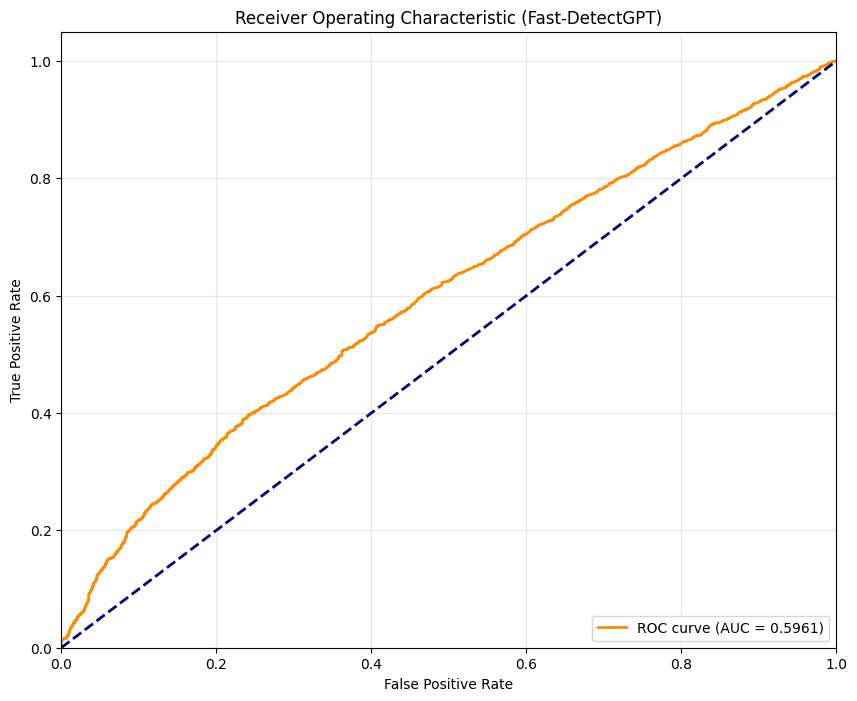

In [6]:
# [Cell 7] Evaluate, Visualize & Save
import matplotlib.pyplot as plt
import json
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc

# 1. Metrics Calculation
y_true = all_results['y_true']
y_scores = all_results['y_scores']

fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

# Find Optimal Threshold (Youden's J statistic)
optimal_idx = np.argmax(tpr - fpr)
optimal_thresh = thresholds[optimal_idx]
y_pred = [1 if s >= optimal_thresh else 0 for s in y_scores]

# Calculate other metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

print(f"\n{'='*60}")
print(f"FINAL SUMMARY (Fast-DetectGPT / Llama-3.2-1B)")
print(f"{'='*60}")
print(f"Dataset:           artnitolog/llm-generated-texts")
print(f"Total Samples:     {len(y_true)}")
print(f"AUC Score:         {roc_auc:.4f}")
print(f"Accuracy:          {acc*100:.2f}%")
print(f"F1 Score:          {f1:.4f}")
print(f"Precision:         {prec:.4f}")
print(f"Recall:            {rec:.4f}")
print(f"Optimal Threshold: {optimal_thresh:.4f}")
print("-" * 60)

# 2. Plot ROC Curve
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (Fast-DetectGPT)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

# 3. Save Results
# Save Plot
plot_path = os.path.join(OUTPUT_DIR, "roc_curve.png")
plt.savefig(plot_path)
print(f"\n✓ Plot saved to: {plot_path}")

# Save JSON Data
final_output = {
    "config": {
        "dataset": "artnitolog/llm-generated-texts",
        "method": "Fast-DetectGPT",
        "scoring_model": "Llama-3.2-1B",
        "perturbation_model": "None (Analytical Curvature)",
        "total_samples": len(y_true)
    },
    "metrics": {
        "auc": roc_auc,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "optimal_threshold": float(optimal_thresh)
    },
    "raw_results": {
        "y_true": y_true,
        "y_scores": y_scores
    }
}

json_path = os.path.join(OUTPUT_DIR, "results.json")
with open(json_path, "w") as f:
    json.dump(final_output, f, indent=4)
print(f"✓ JSON saved to: {json_path}")

plt.show()